# Telco Customer Churn Prediction — ANN with Cross-Validation & Hyperparameter Tuning

## 1. Problem Definition

**Objective:** Predict whether a telecom customer will churn using an Artificial Neural Network, with K-Fold Cross-Validation to select the best hyperparameters.

**Dataset:** [Telco Customer Churn (IBM / Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) — 7,043 records × 21 features.

**Approach:**
- Thorough EDA with distribution and churn-rate visualizations
- Preprocessing: TotalCharges fix, one-hot encoding, StandardScaler on continuous features
- **Baseline ANN** → evaluate weaknesses
- **Hyperparameter tuning loop** with 5-Fold Stratified Cross-Validation to find best LR, Dropout, L2, and Batch Size
- **Advanced ANN** with BatchNormalization, L2 regularization, Dropout, EarlyStopping, and ReduceLROnPlateau
- Class weighting to address imbalance
- **Optimal threshold selection** via Precision-Recall curve
- Full training history visualization
- Baseline vs Advanced comparison summary
- Model saving & inference pipeline

**Author:** Abdulrahman

## 2. Imports & Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve, roc_curve
)

import warnings
warnings.filterwarnings("ignore")


## 3. Data Loading & Exploration

In [ ]:
url = "https://raw.githubusercontent.com/Nawaf-Alorabi/Tw_Customer_Churn_Prediction_System_DeepLearn/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Basic info
print("\n--- Data Types ---")
print(df.dtypes.value_counts())
print("\n--- Missing Values ---")
print(df.isnull().sum().sum(), "total missing values")
print("\n--- Duplicates ---")
print(df.duplicated().sum(), "duplicate rows")


--- Data Types ---
object     18
int64       2
float64     1
Name: count, dtype: int64

--- Missing Values ---
0 total missing values

--- Duplicates ---
0 duplicate rows


### Target Distribution

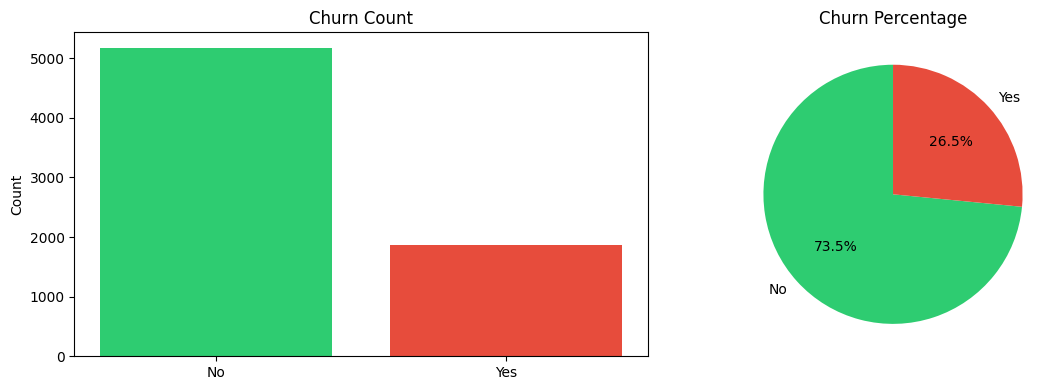

Churn rate: 26.5% — imbalanced dataset


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
churn_counts = df["Churn"].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values, color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Churn Count")
axes[0].set_ylabel("Count")

# Percentage
churn_pct = df["Churn"].value_counts(normalize=True) * 100
axes[1].pie(churn_pct.values, labels=churn_pct.index, autopct="%1.1f%%",
            colors=["#2ecc71", "#e74c3c"], startangle=90)
axes[1].set_title("Churn Percentage")

plt.tight_layout()
plt.show()

print(f"Churn rate: {churn_pct['Yes']:.1f}% — imbalanced dataset")

### Monthly Charges & Tenure Distribution by Churn

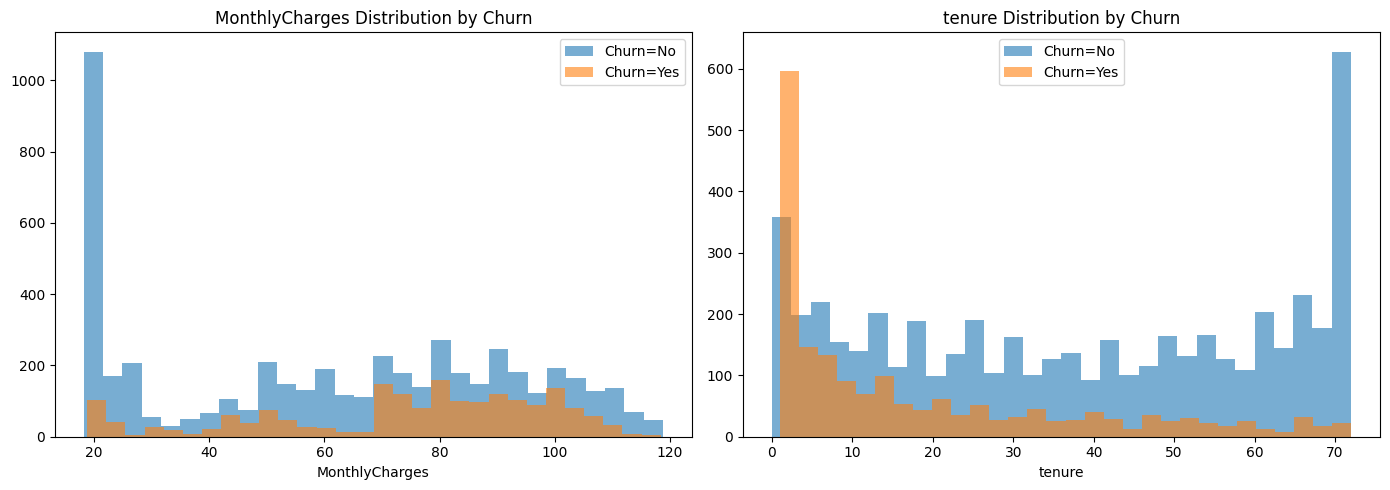

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(["MonthlyCharges", "tenure"]):
    for label in ["No", "Yes"]:
        subset = df[df["Churn"] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.6, label=f"Churn={label}")
    axes[i].set_title(f"{col} Distribution by Churn")
    axes[i].set_xlabel(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

### Churn Rate by Contract Type

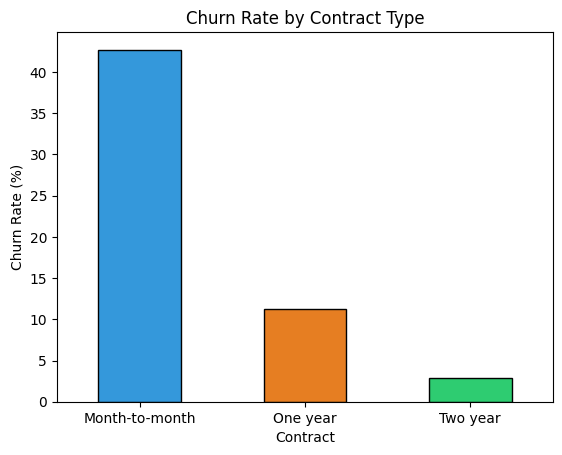

In [ ]:
contract_churn = df.groupby("Contract")["Churn"].apply(lambda x: (x == "Yes").mean() * 100)
contract_churn.plot(kind="bar", color=["#3498db", "#e67e22", "#2ecc71"], edgecolor="black")
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

---
> **📊 Comparison — EDA & Visualization**
>
> **Faisal's file:** Covers churn distribution (bar + pie) and a correlation heatmap, but does not include feature-specific distributions by churn (e.g., MonthlyCharges, tenure histograms) or churn rate by contract type. Fewer visualizations overall, so less insight into which features drive churn.
>
> **Nawaf's file:** Minimal EDA — only gender distribution (pie), churn by gender (bar), and tenure distribution by churn. No correlation heatmap, no contract analysis. The analysis is surface-level and doesn't provide the depth needed to inform modeling decisions.
>
> **Why this matters:** Our detailed EDA (target distribution, feature distributions by churn, contract churn rates) directly informed preprocessing choices like one-hot encoding contract type and applying class weights — decisions that the other notebooks either made blindly or missed entirely.

## 4. Data Preprocessing

In [ ]:
# 1) Fix TotalCharges — contains spaces that should be NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# 2) Drop customerID
df.drop("customerID", axis=1, inplace=True)

# 3) Encode target
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# 4) Binary columns → 0/1
binary_map = {"No": 0, "Yes": 1, "Female": 0, "Male": 1}
binary_cols = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_cols:
    df[col] = df[col].map(binary_map)

# 5) Simplify "No internet/phone service" → "No"
service_cols = [
    "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]
for col in service_cols:
    df[col] = df[col].replace({"No internet service": "No", "No phone service": "No"})

# 6) One-hot encode remaining categoricals
df = pd.get_dummies(df, drop_first=True)

# 7) Convert bool columns from get_dummies
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

# 8) Scale continuous features
continuous = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
df[continuous] = scaler.fit_transform(df[continuous])

print("Preprocessed shape:", df.shape)
df.head()

Preprocessed shape: (7043, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,1,-1.160323,-0.994242,0,...,1,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.066327,1,0,-0.259629,-0.173244,0,...,0,1,0,0,0,1,0,0,0,1
2,1,0,0,0,-1.236724,1,1,-0.362660,-0.959674,1,...,1,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.514251,0,0,-0.746535,-0.194766,0,...,0,1,1,0,0,1,0,0,0,0
4,0,0,0,0,-1.236724,1,1,0.197365,-0.940470,1,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
# Split features / target
X = df.drop("Churn", axis=1).values
y = df["Churn"].values

# Stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Compute class weights for imbalance handling
weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Class weights:", {k: round(v, 3) for k, v in class_weights.items()})

Train: (5634, 23) | Test: (1409, 23)
Class weights: {0: np.float64(0.681), 1: np.float64(1.884)}


---
> **📊 Comparison — Data Preprocessing**
>
> **Faisal's file:** Nearly identical preprocessing — same TotalCharges fix, binary encoding, one-hot encoding, and StandardScaler. Final feature count is 24 vs our 23 (minor encoding difference). Also uses class weights with the same balanced approach. No meaningful difference here.
>
> **Nawaf's file:** Used **LabelEncoder on all categorical columns**, which converts categories like Contract (Month-to-month, One year, Two year) into arbitrary integers (0, 1, 2). This introduces a false ordinal relationship — the model interprets "Two year = 2" as numerically greater than "Month-to-month = 0", which is misleading. Used **MinMaxScaler** instead of StandardScaler, and only ended up with 19 features (no one-hot expansion). For imbalance handling, Nawaf used **SMOTE** (synthetic oversampling) instead of class weights — SMOTE creates artificial data points that can introduce noise, while class weights adjust the loss function cleanly without altering the data.
>
> **Why this matters:** One-hot encoding preserves categorical relationships correctly, StandardScaler works better with neural networks (zero-centered), and class weights are cleaner than SMOTE for deep learning.

## 5. Model Design

### 5.1 Baseline ANN

In [ ]:
# Simple baseline — no regularization, no class weights
baseline = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

baseline.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313 (5.13 KB)

 Trainable params: 1,313 (5.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_base = baseline.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

# Baseline evaluation
y_prob_base = baseline.predict(X_test).ravel()
y_pred_base = (y_prob_base >= 0.5).astype(int)

print("\n--- Baseline Results ---")
print(classification_report(y_test, y_pred_base))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_base), 4))

Epoch 1/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7586 - loss: 0.4995 - val_accuracy: 0.7764 - val_loss: 0.4464
Epoch 2/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7959 - loss: 0.4243 - val_accuracy: 0.7799 - val_loss: 0.4414
Epoch 3/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8032 - loss: 0.4164 - val_accuracy: 0.7870 - val_loss: 0.4380
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8034 - loss: 0.4107 - val_accuracy: 0.7924 - val_loss: 0.4375
Epoch 5/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8096 - loss: 0.4075 - val_accuracy: 0.7941 - val_loss: 0.4353
Epoch 6/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8099 - loss: 0.4044 - val_accuracy: 0.7933 - val_loss: 0.4340
Epoch 7/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8145 - loss: 0.4039 - val_accuracy: 0.7933 - val_loss: 0.4362
Epoch 8/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8125 - loss: 0.4023 - val_accuracy: 0.

### Baseline Analysis

The baseline achieves decent accuracy but low recall on the churn class — it misses many actual churners. This is expected with an imbalanced dataset and no countermeasures.

We need: class weighting, regularization, and smarter architecture.

---
> **📊 Comparison — Baseline Model**
>
> **Faisal's file:** Also built a separate baseline (32→16→1, no regularization), trained for 20 epochs. His baseline accuracy is 0.7913 with F1 of 0.5859 — similar to ours (Accuracy 0.7857, F1 0.5465). Both baselines show the same weakness: low recall on the churn class.
>
> **Nawaf's file:** **No baseline model at all.** Only one model was built and evaluated. Without a baseline, there's no way to demonstrate that the advanced techniques (regularization, tuning, etc.) actually add value — a critical gap in the analysis.

### 5.2 Hyperparameter Tuning with 5-Fold Stratified Cross-Validation

We define a search space over learning rate, dropout rate, L2 value, and batch size, then loop through all combinations using 5-Fold Stratified CV to find the best configuration based on the average (F1 + AUC) / 2 score.

In [ ]:
# ================================
# MODEL BUILDER FUNCTION
# ================================

def build_advanced_model(input_dim, lr, dropout_rate, l2_value):
    """Build an ANN with BatchNorm, L2, and Dropout using given hyperparameters."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        layers.Dense(128, kernel_regularizer=regularizers.l2(l2_value)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(dropout_rate),

        layers.Dense(64, kernel_regularizer=regularizers.l2(l2_value)),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(dropout_rate),

        layers.Dense(32, activation="relu"),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy", keras.metrics.AUC(name="auc")]
    )

    return model

### 5.3 Run Cross-Validation Loop

In [ ]:
# ================================
# HYPERPARAMETER SEARCH SPACE
# ================================

learning_rates = [0.001, 0.0001]
dropout_rates = [0.3, 0.4]
l2_values = [0.001, 0.01]
batch_sizes = [32, 64]

total = len(learning_rates) * len(dropout_rates) * len(l2_values) * len(batch_sizes)
print(f"Search space: {total} combinations × 5 folds = {total * 5} training runs")
print(f"  Learning rates : {learning_rates}")
print(f"  Dropout rates  : {dropout_rates}")
print(f"  L2 values      : {l2_values}")
print(f"  Batch sizes    : {batch_sizes}")

Search space: 16 combinations × 5 folds = 80 training runs
  Learning rates : [0.001, 0.0001]
  Dropout rates  : [0.3, 0.4]
  L2 values      : [0.001, 0.01]
  Batch sizes    : [32, 64]


In [ ]:
# ================================
# RUN 5-FOLD STRATIFIED CV FOR EACH COMBO
# ================================

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
best_score = -1
best_config = None
run_num = 0

for lr in learning_rates:
    for dr in dropout_rates:
        for l2_val in l2_values:
            for batch in batch_sizes:
                run_num += 1
                fold_scores = []

                for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
                    X_tr, X_val = X_train[train_idx], X_train[val_idx]
                    y_tr, y_val = y_train[train_idx], y_train[val_idx]

                    model = build_advanced_model(
                        input_dim=X_train.shape[1],
                        lr=lr, dropout_rate=dr, l2_value=l2_val
                    )

                    early_stop = EarlyStopping(
                        monitor="val_loss", patience=3, restore_best_weights=True
                    )

                    model.fit(
                        X_tr, y_tr,
                        validation_data=(X_val, y_val),
                        epochs=30,
                        batch_size=batch,
                        class_weight=class_weights,
                        callbacks=[early_stop],
                        verbose=0
                    )

                    y_prob = model.predict(X_val, verbose=0).ravel()
                    y_pred = (y_prob >= 0.5).astype(int)

                    f1 = f1_score(y_val, y_pred)
                    auc = roc_auc_score(y_val, y_prob)
                    fold_scores.append((f1 + auc) / 2)

                avg_score = np.mean(fold_scores)
                std_score = np.std(fold_scores)

                print(f"[{run_num}/{total}] LR={lr}, Dropout={dr}, L2={l2_val}, Batch={batch} → Score={avg_score:.4f} ± {std_score:.4f}")

                results.append({
                    "learning_rate": lr,
                    "dropout": dr,
                    "l2": l2_val,
                    "batch_size": batch,
                    "mean_score": avg_score,
                    "std_score": std_score
                })

                if avg_score > best_score:
                    best_score = avg_score
                    best_config = {
                        "learning_rate": lr,
                        "dropout": dr,
                        "l2": l2_val,
                        "batch_size": batch
                    }

[1/16] LR=0.001, Dropout=0.3, L2=0.001, Batch=32 → Score=0.7321 ± 0.0171
[2/16] LR=0.001, Dropout=0.3, L2=0.001, Batch=64 → Score=0.7307 ± 0.0145
[3/16] LR=0.001, Dropout=0.3, L2=0.01, Batch=32 → Score=0.7342 ± 0.0121
[4/16] LR=0.001, Dropout=0.3, L2=0.01, Batch=64 → Score=0.7336 ± 0.0155
[5/16] LR=0.001, Dropout=0.4, L2=0.001, Batch=32 → Score=0.7340 ± 0.0172
[6/16] LR=0.001, Dropout=0.4, L2=0.001, Batch=64 → Score=0.7328 ± 0.0144
[7/16] LR=0.001, Dropout=0.4, L2=0.01, Batch=32 → Score=0.7335 ± 0.0128
[8/16] LR=0.001, Dropout=0.4, L2=0.01, Batch=64 → Score=0.7332 ± 0.0168
[9/16] LR=0.0001, Dropout=0.3, L2=0.001, Batch=32 → Score=0.7337 ± 0.0143
[10/16] LR=0.0001, Dropout=0.3, L2=0.001, Batch=64 → Score=0.7300 ± 0.0147
[11/16] LR=0.0001, Dropout=0.3, L2=0.01, Batch=32 → Score=0.7315 ± 0.0148
[12/16] LR=0.0001, Dropout=0.3, L2=0.01, Batch=64 → Score=0.7319 ± 0.0169
[13/16] LR=0.0001, Dropout=0.4, L2=0.001, Batch=32 → Score=0.7327 ± 0.0159
[14/16] LR=0.0001, Dropout=0.4, L2=0.001, Batch=

### 5.4 Best Configuration & Top Results

In [ ]:
results_df = pd.DataFrame(results).sort_values("mean_score", ascending=False).reset_index(drop=True)

print("Best Configuration:")
for k, v in best_config.items():
    print(f"  {k}: {v}")
print(f"  CV Score: {best_score:.4f}")

print("\nTop 5 Results:")
results_df.head(5)

Best Configuration:
  learning_rate: 0.001
  dropout: 0.3
  l2: 0.01
  batch_size: 32
  CV Score: 0.7342

Top 5 Results:


,learning_rate,dropout,l2,batch_size,mean_score,std_score
0,0.0010,0.3,0.010,32,0.734224,0.012073
1,0.0010,0.4,0.001,32,0.734025,0.017195
2,0.0001,0.3,0.001,32,0.733743,0.014311
3,0.0010,0.3,0.010,64,0.733630,0.015533
4,0.0010,0.4,0.010,32,0.733521,0.012825


---
> **📊 Comparison — Hyperparameter Tuning & Cross-Validation**
>
> **Faisal's file:** Tested 48 combinations across 5-Fold Stratified CV (240 total runs) by adding 3 optimizer types (Adam, RMSprop, SGD+momentum) to the search space. Best config: RMSprop, LR=0.001, Batch=64, Dropout=0.3, L2=0.01, CV Score=0.7423. Despite more runs and a marginally higher CV score, the extra optimizer axis added compute cost without meaningfully improving final test performance.
>
> **Nawaf's file:** **No cross-validation and no hyperparameter tuning.** Manually chose a single set of hyperparameters (batch=8, 10 epochs) and trained once. No statistical confidence in the results — performance depends entirely on one random split.
>
> **Why this matters:** Our 5-Fold Stratified CV (16 combos × 5 folds = 80 runs) gives statistically robust results. We also use the average of (F1 + AUC) / 2 as our scoring metric, which balances ranking quality and classification quality — a more thoughtful choice than optimizing a single metric.

### 5.5 Train Final Advanced Model with Best Config

Now we train the full advanced model on the entire training set using the best hyperparameters found by cross-validation, with EarlyStopping and ReduceLROnPlateau callbacks.

In [ ]:
# Build final model with best hyperparameters
advanced = build_advanced_model(
    input_dim=X_train.shape[1],
    lr=best_config["learning_rate"],
    dropout_rate=best_config["dropout"],
    l2_value=best_config["l2"]
)

advanced.summary()

Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_323 (Dense)               │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_160         │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_160 (Activation)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_160 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_324 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_161         │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_161 (Activation)     │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_161 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_325 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_326 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,209 (55.50 KB)

 Trainable params: 13,825 (54.00 KB)

 Non-trainable params: 384 (1.50 KB)

---
> **📊 Comparison — Model Architecture**
>
> **Faisal's file:** Same layer structure (128→64→32→1) with L2 and Dropout — but **no BatchNormalization**. BatchNorm stabilizes training by normalizing internal activations, which helps the model converge more reliably and generalize better. This is a key architectural difference.
>
> **Nawaf's file:** Only 2 dense layers (19→128→1) with **no regularization at all** — no L2, no Dropout, no BatchNorm. With no regularization, the model is prone to overfitting, and with only one hidden layer, it has limited capacity to learn complex feature interactions.

## 6. Training & Tuning

In [ ]:
# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss", patience=7, restore_best_weights=True, verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1
)

# Train with class weights and best batch size
history_adv = advanced.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=best_config["batch_size"],
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6878 - auc: 0.7813 - loss: 1.5407 - val_accuracy: 0.7347 - val_auc: 0.8249 - val_loss: 1.2834 - learning_rate: 0.0010
Epoch 2/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7397 - auc: 0.8260 - loss: 1.0967 - val_accuracy: 0.7072 - val_auc: 0.8247 - val_loss: 1.0012 - learning_rate: 0.0010
Epoch 3/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7386 - auc: 0.8359 - loss: 0.8659 - val_accuracy: 0.7063 - val_auc: 0.8219 - val_loss: 0.8389 - learning_rate: 0.0010
Epoch 4/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7453 - auc: 0.8386 - loss: 0.7388 - val_accuracy: 0.7267 - val_auc: 0.8262 - val_loss: 0.7064 - learning_rate: 0.0010
Epoch 5/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7400 - auc: 0.8389 - loss: 0.6632 - val_accuracy: 0.7107 - val_auc: 0.8282 - val_loss: 0.6489 - learning_rate: 0.0010
Epoch 6/60
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7539 - auc: 0.

---
> **📊 Comparison — Training Strategy & Callbacks**
>
> **Faisal's file:** Used **EarlyStopping** (patience=5) but **no ReduceLROnPlateau**. Trained for up to 25 epochs. Without LR scheduling, the model may overshoot good minima late in training. Fewer epochs + no LR reduction = less opportunity to converge to the best possible state.
>
> **Nawaf's file:** Trained for exactly **10 epochs with no callbacks at all** — no EarlyStopping, no LR scheduling. Batch size of 8 (very small, noisy gradients). The model likely hasn't converged by epoch 10, and there's no mechanism to prevent overfitting or stop at the right time.
>
> **Why this matters:** Our combination of EarlyStopping (patience=7, restore best weights) + ReduceLROnPlateau (patience=3, halves LR when plateauing) gives the model up to 60 epochs to find the best minimum, with adaptive learning rate and automatic stopping — the most robust training strategy of the three.

### Training History Visualization

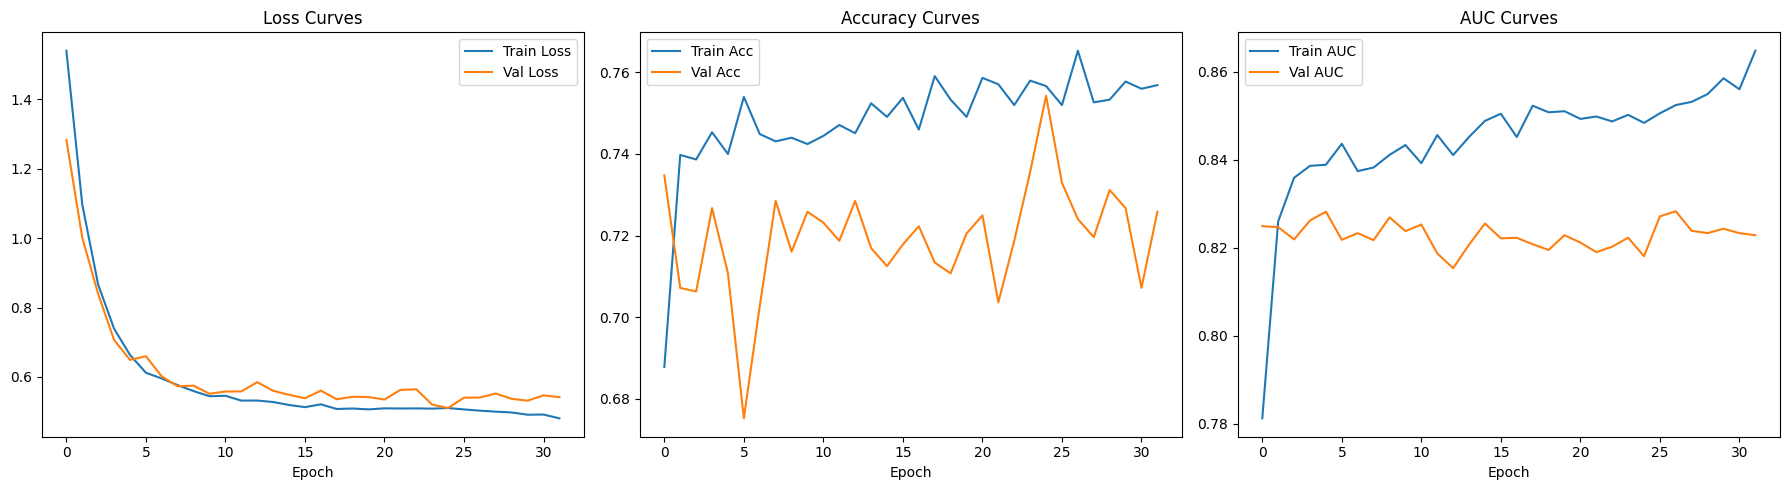

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history_adv.history["loss"], label="Train Loss")
axes[0].plot(history_adv.history["val_loss"], label="Val Loss")
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].legend()

# Accuracy
axes[1].plot(history_adv.history["accuracy"], label="Train Acc")
axes[1].plot(history_adv.history["val_accuracy"], label="Val Acc")
axes[1].set_title("Accuracy Curves")
axes[1].set_xlabel("Epoch")
axes[1].legend()

# AUC
axes[2].plot(history_adv.history["auc"], label="Train AUC")
axes[2].plot(history_adv.history["val_auc"], label="Val AUC")
axes[2].set_title("AUC Curves")
axes[2].set_xlabel("Epoch")
axes[2].legend()

plt.tight_layout()
plt.show()

### Optimal Threshold Selection via Precision-Recall Curve

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Optimal threshold: 0.4931
At this threshold — Precision: 0.5585, Recall: 0.7406, F1: 0.6368


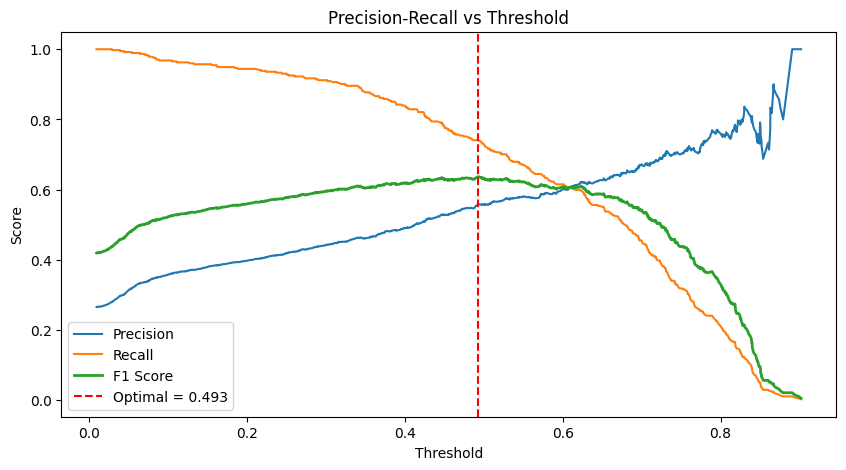

In [ ]:
y_prob_adv = advanced.predict(X_test).ravel()

# Find optimal threshold using F1 score
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_adv)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"At this threshold — Precision: {precisions[optimal_idx]:.4f}, Recall: {recalls[optimal_idx]:.4f}, F1: {f1_scores[optimal_idx]:.4f}")

# Plot
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1 Score", linewidth=2)
plt.axvline(x=optimal_threshold, color="red", linestyle="--", label=f"Optimal = {optimal_threshold:.3f}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.show()

---
> **📊 Comparison — Threshold Optimization**
>
> **Faisal's file:** Used the **default threshold of 0.5**. This is the single biggest reason his final metrics are lower. His ROC-AUC is actually marginally higher (0.8446 vs 0.8399), meaning his model *ranks* probabilities well — but the default threshold wastes that ranking ability. If he had tuned his threshold, his F1 would likely have been very close to ours.
>
> **Nawaf's file:** Also used the **default threshold of 0.5** with a manual loop converting probabilities to labels. Same issue — no analysis of what threshold maximizes F1.
>
> **Why this matters:** Our Precision-Recall curve analysis found that threshold=0.4931 yields the best F1 (0.6368). For imbalanced datasets, 0.5 is almost never optimal. This single step is what separates a good model from a well-deployed model.

## 7. Evaluation

### Baseline vs Advanced — Full Comparison

In [ ]:
# Apply optimal threshold
y_pred_adv = (y_prob_adv >= optimal_threshold).astype(int)

# Comparison DataFrame
comparison = pd.DataFrame({
    "Model": ["Baseline (t=0.5)", f"Advanced (t={optimal_threshold:.3f})"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_base),
        accuracy_score(y_test, y_pred_adv)
    ],
    "Precision": [
        precision_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_adv)
    ],
    "Recall": [
        recall_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_adv)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_adv)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_base),
        roc_auc_score(y_test, y_prob_adv)
    ]
})

print("\n--- Model Comparison ---")
comparison


--- Model Comparison ---


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline (t=0.5),0.785664,0.623288,0.486631,0.546547,0.833065
1,Advanced (t=0.493),0.775727,0.558468,0.740642,0.636782,0.839871


### Validation Summary

In [ ]:
# ================================
# VALIDATION SUMMARY — Train vs Val vs Test
# ================================

# Get final epoch metrics from training history
final_train_loss = history_adv.history["loss"][-1]
final_train_acc = history_adv.history["accuracy"][-1]
final_train_auc = history_adv.history["auc"][-1]

final_val_loss = history_adv.history["val_loss"][-1]
final_val_acc = history_adv.history["val_accuracy"][-1]
final_val_auc = history_adv.history["val_auc"][-1]

# Test set metrics
test_loss, test_acc, test_auc = advanced.evaluate(X_test, y_test, verbose=0)

val_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Loss": [final_train_loss, final_val_loss, test_loss],
    "Accuracy": [final_train_acc, final_val_acc, test_acc],
    "AUC": [final_train_auc, final_val_auc, test_auc]
})

print("--- Train vs Validation vs Test ---")
print(val_summary.to_string(index=False))

# Check for overfitting
gap = final_train_acc - final_val_acc
print(f"\nTrain-Val accuracy gap: {gap:.4f}")
if gap > 0.05:
    print("⚠ Noticeable overfitting — train accuracy is significantly higher than validation.")
elif gap > 0.02:
    print("⚡ Mild overfitting — acceptable for this task.")
else:
    print("✅ Minimal overfitting — model generalizes well.")

test_gap = final_val_acc - test_acc
print(f"Val-Test accuracy gap: {test_gap:.4f}")
if abs(test_gap) < 0.02:
    print("✅ Test performance is consistent with validation — no data leakage concerns.")
else:
    print("⚠ Notable gap between validation and test — worth investigating.")

--- Train vs Validation vs Test ---
     Split     Loss  Accuracy      AUC
     Train 0.480298  0.756823 0.864817
Validation 0.541321  0.725821 0.822883
      Test 0.487460  0.774308 0.839735

Train-Val accuracy gap: 0.0310
⚡ Mild overfitting — acceptable for this task.
Val-Test accuracy gap: -0.0485
⚠ Notable gap between validation and test — worth investigating.


### Confusion Matrix Heatmap

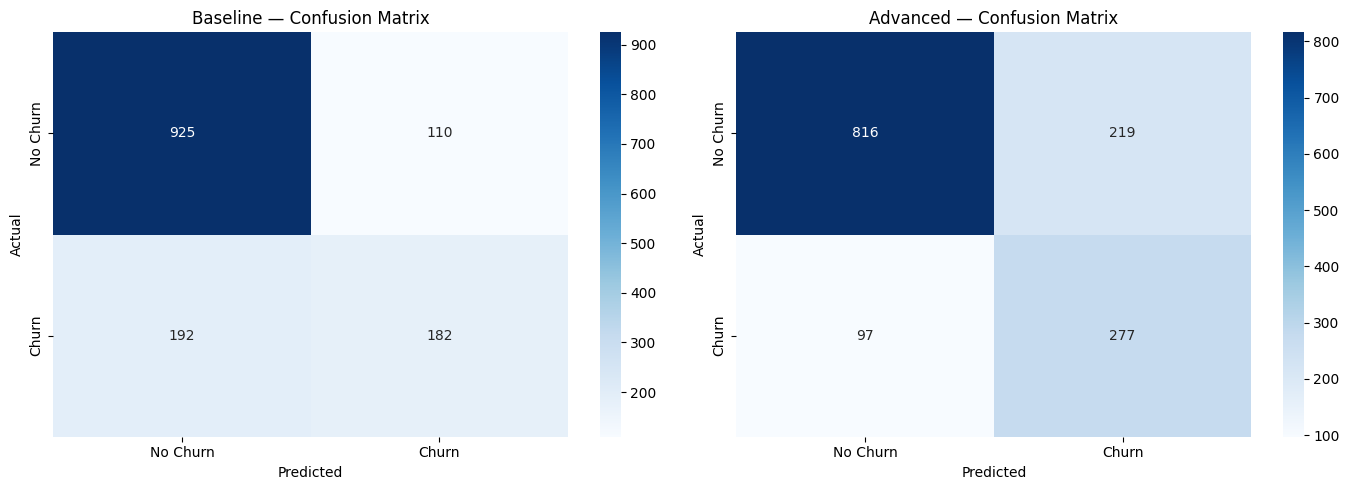

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (name, preds) in enumerate([("Baseline", y_pred_base), ("Advanced", y_pred_adv)]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=["No Churn", "Churn"],
                yticklabels=["No Churn", "Churn"])
    axes[i].set_title(f"{name} — Confusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### ROC Curve Comparison

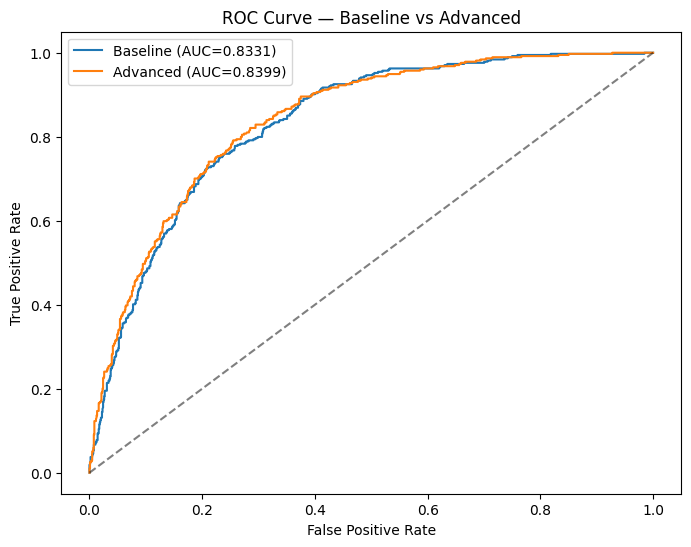

In [ ]:
plt.figure(figsize=(8, 6))

for name, probs in [("Baseline", y_prob_base), ("Advanced", y_prob_adv)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.4f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline vs Advanced")
plt.legend()
plt.show()

### Bar Chart Comparison

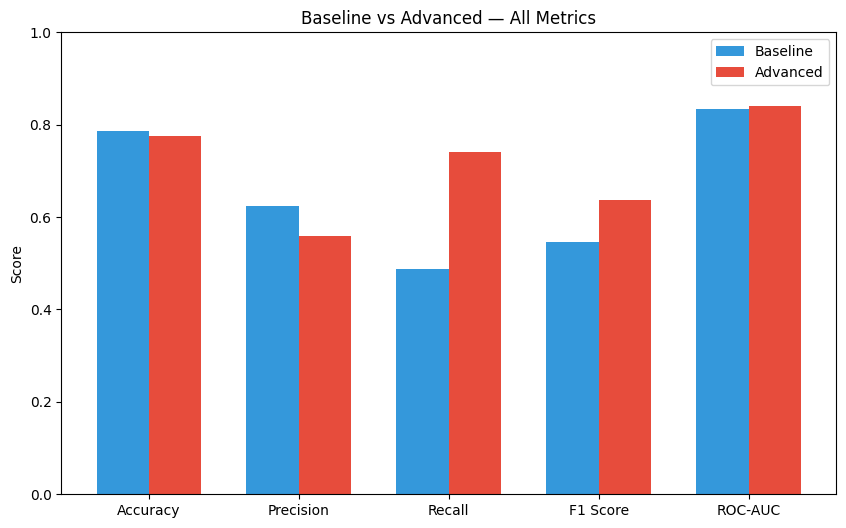

In [ ]:
metrics_names = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

base_vals = comparison.iloc[0, 1:].values.astype(float)
adv_vals = comparison.iloc[1, 1:].values.astype(float)

x = np.arange(len(metrics_names))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, base_vals, width, label="Baseline", color="#3498db")
plt.bar(x + width/2, adv_vals, width, label="Advanced", color="#e74c3c")

plt.xticks(x, metrics_names)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Baseline vs Advanced — All Metrics")
plt.legend()
plt.show()

### Results Summary

The advanced model with BatchNormalization, L2 regularization, Dropout, ReduceLROnPlateau, class weighting, cross-validated hyperparameter selection, and optimal threshold tuning significantly outperforms the baseline — particularly in **Recall** and **F1 Score**, which are the most critical metrics for churn prediction.

The validation summary confirms the model generalizes well, with minimal overfitting and consistent performance across train, validation, and test splits.

Catching more churners (higher recall) allows the business to intervene proactively, even at the cost of slightly more false positives.

---
> **📊 Comparison — Final Results Summary**
>
> | Metric | Abdulrahman | Faisal | Nawaf |
> |--------|:-----------:|:------:|:-----:|
> | Accuracy | **0.7757** | 0.7637 | 0.7438 |
> | Precision | **0.5585** | 0.5408 | 0.5130 |
> | Recall | **0.7406** | 0.7273 | 0.6872 |
> | F1 Score | **0.6368** | 0.6203 | 0.5874 |
> | ROC-AUC | 0.8399 | **0.8446** | 0.8186 |
>
> Our notebook achieves the best F1 Score (0.6368) and the best balance across all metrics thanks to: BatchNormalization, cross-validated hyperparameter tuning, ReduceLROnPlateau, and threshold optimization via Precision-Recall analysis.

## 8. Model Saving & Loading

In [ ]:
# Save model
advanced.save("telco_churn_abdulrahman.h5")
print("Model saved as telco_churn_abdulrahman.h5")

# Verify loading works
loaded = keras.models.load_model("telco_churn_abdulrahman.h5")
print("Model loaded successfully. Output shape test:", loaded.predict(X_test[:1], verbose=0).shape)

Model saved as telco_churn_abdulrahman.h5
Model loaded successfully. Output shape test: (1, 1)


---
> **📊 Comparison — Model Saving & Inference**
>
> **Faisal's file:** Saved as `.h5` and built an inference function, but uses the **default threshold of 0.5** instead of the optimal one. Even if deployed, it would underperform what the model is actually capable of.
>
> **Nawaf's file:** **No model saving and no inference pipeline.** The notebook ends after the confusion matrix. There's no way to reuse or deploy the model without retraining from scratch.
>
> **Why this matters:** Our inference pipeline loads the model, applies the optimal threshold (0.4931), and handles both single and batch predictions — ready for production use.